<a href="https://colab.research.google.com/github/ritvik94/Image_based_vegetable_identification/blob/main/Custom_Resnet18_Image_based_Vegetable_identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.cuda.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
from PIL import Image
import numpy as np
import kagglehub
import os
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from tqdm.auto import tqdm
import warnings

In [ ]:
warnings.filterwarnings("ignore")

In [ ]:
path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\misrakahmed\vegetable-image-dataset\versions\1


In [ ]:
import os

def inspect_dataset(base_path):
    print(f"Inspecting root directory: {base_path}\n")

    top_items = os.listdir(base_path)
    print(f"Top-level contents: {top_items}\n")

    for item in top_items:
        item_path = os.path.join(base_path, item)
        if os.path.isdir(item_path):
            sub_items = os.listdir(item_path)
            print(f"Inside folder '{item}':")
            print(f"  - Total sub-folders/files: {len(sub_items)}")
            print(f"  - First 5 items: {sub_items[:5]}\n")

inspect_dataset(path)

Inspecting root directory: C:\Users\User\.cache\kagglehub\datasets\misrakahmed\vegetable-image-dataset\versions\1

Top-level contents: ['Vegetable Images']

Inside folder 'Vegetable Images':
  - Total sub-folders/files: 3
  - First 5 items: ['test', 'train', 'validation']



In [ ]:
class ResidualBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride = 1, downsample = None):
    super(ResidualBlock, self).__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1, bias = False)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU(inplace = True)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size = 3, padding = 1, bias = False)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.downsample = downsample

  def forward(self, x):
    identity = x

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)

    if self.downsample is not None:
      identity = self.downsample(x)

    out += identity
    out = self.relu(out)

    return out

In [ ]:
def initialize_weights(m):
  if isinstance(m, nn.Conv2d):
    nn.init.kaiming_normal_(m.weight, mode = 'fan_out', nonlinearity = 'relu')
  elif isinstance(m, nn.BatchNorm2d):
    nn.init.constant_(m.weight, 1)
    nn.init.constant_(m.bias, 0)

In [ ]:
class ResNet18(nn.Module):
  def __init__(self, num_classes = 1000):
    super(ResNet18, self).__init__()
    self.in_channels = 64
    self.conv1 = nn.Conv2d(3,64, kernel_size = 7, stride = 2, padding = 3, bias = False)
    self.bn1 = nn.BatchNorm2d(64)
    self.relu = nn.ReLU(inplace = True)
    self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

    self.layer1 = self._make_layer(64, 2)
    self.layer2 = self._make_layer(128, 2, stride = 2)
    self.layer3 = self._make_layer(256, 2, stride = 2)
    self.layer4 = self._make_layer(512, 2, stride = 2)

    self.avgpool = nn.AdaptiveAvgPool2d((1,1))
    self.fc = nn.Linear(512, num_classes)

    self.apply(initialize_weights)


  def _make_layer(self, out_channels, blocks, stride = 1):
    downsample = None
    if stride != 1 or self.in_channels != out_channels:
      downsample = nn.Sequential(
          nn.Conv2d(self.in_channels, out_channels, kernel_size = 1, stride = stride, bias = False),
          nn.BatchNorm2d(out_channels)
      )
    layers = [ResidualBlock(self.in_channels, out_channels, stride, downsample)]
    self.in_channels = out_channels
    for _ in range(1, blocks):
      layers.append(ResidualBlock(out_channels, out_channels))
    return nn.Sequential(*layers)


  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)

    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.fc(x)

    return x

In [ ]:
train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    A.Normalize(mean=(0.485, 0.456, 0.405), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

def apply_transforms(image):
  return train_transforms(image = image)["image"]

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs):
    model = model.to(device)

    writer = SummaryWriter()

    best_val_acc = 0.0

    for epoch in range(num_epochs):

        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        current_lr = optimizer.param_groups[0]['lr']
        print(f"\n[{'-'*15} Epoch {epoch+1}/{num_epochs} | LR: {current_lr:.6f} {'-'*15}]")

        progress_bar = tqdm(train_loader, desc="Training", leave=False)

        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()


            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()


            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()

            progress_bar.set_postfix(loss=f"{loss.item():.4f}")

        train_epoch_loss = running_loss / len(train_loader.dataset)
        train_epoch_acc = 100. * correct_train / total_train

        model.eval()
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total_val += labels.size(0)
                correct_val += predicted.eq(labels).sum().item()

        val_epoch_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_acc = 100. * correct_val / total_val

        writer.add_scalar('Loss/train', train_epoch_loss, epoch)
        writer.add_scalar('Loss/val', val_epoch_loss, epoch)
        writer.add_scalar('Accuracy/train', train_epoch_acc, epoch)
        writer.add_scalar('Accuracy/val', val_epoch_acc, epoch)

        print(f"Train -> Loss: {train_epoch_loss:.4f} | Accuracy: {train_epoch_acc:.2f}%")
        print(f"Val   -> Loss: {val_epoch_loss:.4f} | Accuracy: {val_epoch_acc:.2f}%")

        scheduler.step()

        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            torch.save(model.state_dict(), 'best_resnet18.pth')
            print(f"🌟 New best model saved! (Val Acc: {best_val_acc:.2f}%)")

    writer.close()

In [ ]:
class AlbumentationsDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.data = ImageFolder(root_dir)
        self.transform = transform
        self.classes = self.data.classes

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data.samples[idx]
        image = np.array(Image.open(img_path).convert("RGB"))

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, label

In [ ]:
def evaluate_model(model, dataloader, device):
  model.eval()
  all_labels = []
  all_preds = []
  all_probs = []

  with torch.no_grad():
    for inputs, labels in dataloader:
      inputs = inputs.to(device)
      outputs = model(inputs)

      probs = F.softmax(outputs, dim=1)
      preds = torch.argmax(outputs, dim=1)

      all_labels.extend(labels.cpu().numpy())
      all_preds.extend(preds.cpu().numpy())
      all_probs.extend(probs.cpu().numpy())

  acc = accuracy_score(all_labels, all_preds)
  f1 = f1_score(all_labels, all_preds, average = 'weighted')
  roc_auc = roc_auc_score(all_labels, all_probs, average = 'weighted', multi_class = 'ovr')


  print(f'Accuracy:  {acc * 100:.2f}%')
  print(f'F1 Score:  {f1:.4f}')
  print(f'ROC-AUC:   {roc_auc:.4f}')
  print(f'Confusion Matrix:\n{confusion_matrix(all_labels, all_preds)}')

In [ ]:
def load_and_preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    val_transforms = A.Compose([
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.405), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

    tensor = val_transforms(image=image_np)["image"]
    return tensor.unsqueeze(0)

In [ ]:
def visualize_prediction(model, image_path, device, class_names):
    model.eval()
    image_tensor = load_and_preprocess_image(image_path).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        predicted_idx = output.argmax(dim=1).item()

        predicted_breed = class_names[predicted_idx]

    image = Image.open(image_path).convert("RGB")
    plt.imshow(image)
    plt.title(f"Predicted Vegetable: {predicted_breed}")
    plt.axis('off')
    plt.show()

In [ ]:
train_path = os.path.join(path, "Vegetable Images", "train")
val_path = os.path.join(path, "Vegetable Images", "validation")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

val_transforms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.405), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# 1. Load the datasets from their respective folders
full_train_dataset = AlbumentationsDataset(root_dir=train_path, transform=train_transforms)
full_val_dataset = AlbumentationsDataset(root_dir=val_path, transform=val_transforms)

# 2. Skip the train_test_split entirely! Pass them directly to the DataLoaders
train_loader = DataLoader(full_train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(full_val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Training on {len(full_train_dataset)} images, Validating on {len(full_val_dataset)} images.")

# 3. Setup Model, Loss, Optimizer
num_classes = len(full_train_dataset.classes)
model = ResNet18(num_classes=num_classes)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# 4. Run Training
num_epochs = 30
print("\nStarting training...")
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs)
print("\nEvaluating model on validation set...")
evaluate_model(model, val_loader, device)

Using device: cuda
Training on 15000 images, Validating on 3000 images.

Starting training...

[--------------- Epoch 1/30 | LR: 0.001000 ---------------]


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Train -> Loss: 1.3700 | Accuracy: 68.77%
Val   -> Loss: 1.2536 | Accuracy: 73.37%
🌟 New best model saved! (Val Acc: 73.37%)

[--------------- Epoch 2/30 | LR: 0.001000 ---------------]


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Train -> Loss: 0.9500 | Accuracy: 87.02%
Val   -> Loss: 0.8729 | Accuracy: 89.73%
🌟 New best model saved! (Val Acc: 89.73%)

[--------------- Epoch 3/30 | LR: 0.001000 ---------------]


...

Train -> Loss: 0.5669 | Accuracy: 99.89%
Val   -> Loss: 0.5952 | Accuracy: 98.53%

[--------------- Epoch 29/30 | LR: 0.000250 ---------------]


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Train -> Loss: 0.5651 | Accuracy: 99.95%
Val   -> Loss: 0.5637 | Accuracy: 99.83%

[--------------- Epoch 30/30 | LR: 0.000250 ---------------]


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Train -> Loss: 0.5618 | Accuracy: 99.99%
Val   -> Loss: 0.5630 | Accuracy: 99.83%

Evaluating model on validation set...
Accuracy:  99.83%
F1 Score:  0.9983
ROC-AUC:   1.0000
Confusion Matrix:
[[199   0   0   1   0   0   0   0   0   0   0   0   0   0   0]
 [  0 200   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 200   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 199   0   0   0   0   0   0   0   0   1   0   0]
 [  0   0   0   0 200   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 200   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 200   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 200   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 200   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 200   0   0   0   0   0]
 [  0   0   0   2   0   0   0   0   0   0 197   0   0   0   1]
 [  0   0   0   0   0   0   0   0   0   0   0 200   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 2

Testing 5 random images from the validation set...



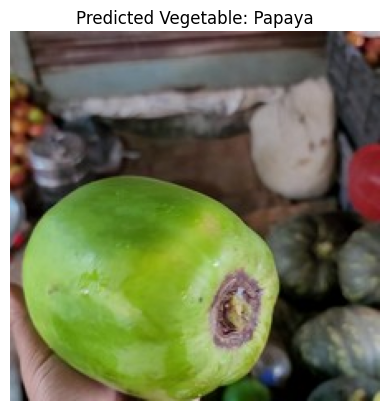

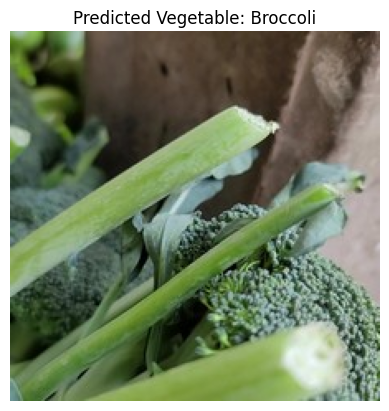

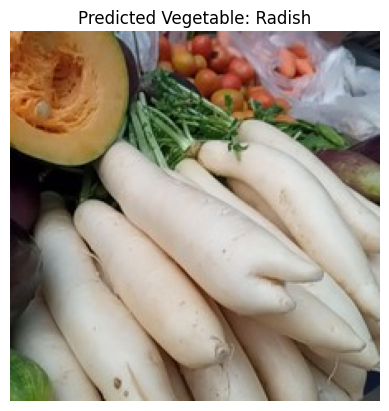

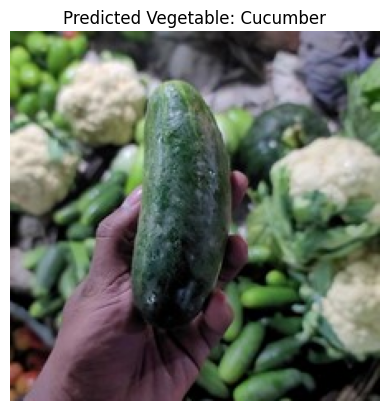

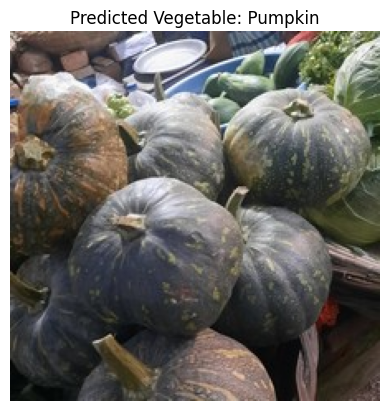

In [ ]:
import random

class_names = full_val_dataset.classes

# FIX: Sample from the total length of the dataset instead of .indices
random_indices = random.sample(range(len(full_val_dataset)), 5)

print("Testing 5 random images from the validation set...\n")

for idx in random_indices:
    image_path = full_val_dataset.data.samples[idx][0]

    visualize_prediction(model, image_path, device, class_names)